In [1]:
import os
import time
import ast
import torch
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision import models

import cv2

warnings.filterwarnings('ignore')


In [2]:
DEVICE = torch.device("cpu")

print("Using device :", DEVICE)

Using device : cpu


In [3]:
DATASET_PATH = r"C:\Users\gaida\OneDrive - SUPCOM\Desktop\p2m\finale\processed_dataset"

train_df = pd.read_csv(
    os.path.join(DATASET_PATH, "train.csv")
)

val_df = pd.read_csv(
    os.path.join(DATASET_PATH, "val.csv")
)

test_df = pd.read_csv(
    os.path.join(DATASET_PATH, "test.csv")
)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)


(77450, 38)
(13648, 38)
(16008, 38)


In [4]:
train_df['Label'] = train_df['FilteredLabels'].apply(
    lambda x: ast.literal_eval(x)[0]
)

val_df['Label'] = val_df['FilteredLabels'].apply(
    lambda x: ast.literal_eval(x)[0]
)

test_df['Label'] = test_df['FilteredLabels'].apply(
    lambda x: ast.literal_eval(x)[0]
)


In [5]:
label_encoder = LabelEncoder()

train_df['EncodedLabel'] = label_encoder.fit_transform(
    train_df['Label']
)

val_df['EncodedLabel'] = label_encoder.transform(
    val_df['Label']
)

test_df['EncodedLabel'] = label_encoder.transform(
    test_df['Label']
)


In [6]:
# IMPORTANT:
# Reduce dataset size for CPU

train_df = train_df.sample(
    5000,
    random_state=42
)

val_df = val_df.sample(
    1000,
    random_state=42
)

test_df = test_df.sample(
    1000,
    random_state=42
)

print("\nReduced Dataset Size")
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)


Reduced Dataset Size
(5000, 40)
(1000, 40)
(1000, 40)


In [7]:
IMG_SIZE = 224

BATCH_SIZE = 8

EPOCHS = 3

LEARNING_RATE = 1e-4

NUM_CLASSES = train_df['EncodedLabel'].nunique()

print("Number of Classes :", NUM_CLASSES)

Number of Classes : 14


In [8]:
train_transforms = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

val_transforms = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])


In [9]:
class PADChestDataset(Dataset):

    def __init__(self,
                 dataframe,
                 transforms=None):

        self.dataframe = dataframe
        self.transforms = transforms

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = row['ImagePath']

        label = row['EncodedLabel']

        # Read image
        image = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        # Apply transforms
        if self.transforms:

            image = self.transforms(image)

        return image, label

In [10]:
train_dataset = PADChestDataset(
    train_df,
    transforms=train_transforms
)

val_dataset = PADChestDataset(
    val_df,
    transforms=val_transforms
)

test_dataset = PADChestDataset(
    test_df,
    transforms=val_transforms
)

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created successfully")

DataLoaders created successfully


In [12]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['EncodedLabel']),
    y=train_df['EncodedLabel']
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(DEVICE)

In [13]:
model = models.mobilenet_v2(
    pretrained=True
)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\gaida/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:08<00:00, 1.60MB/s]


In [14]:
model.features[0][0] = nn.Conv2d(
    1,
    32,
    kernel_size=3,
    stride=2,
    padding=1,
    bias=False
)


In [15]:
model.classifier = nn.Sequential(

    nn.Dropout(0.2),

    nn.Linear(
        model.last_channel,
        NUM_CLASSES
    )
)


In [16]:
model = model.to(DEVICE)

In [17]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


In [18]:

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [19]:
def train_one_epoch(model,
                    dataloader,
                    criterion,
                    optimizer):

    model.train()

    running_loss = 0

    predictions = []

    true_labels = []

    loop = tqdm(dataloader)

    for images, labels in loop:

        images = images.to(DEVICE)

        labels = labels.to(DEVICE)

        # Forward
        outputs = model(images)

        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        # Predictions
        _, preds = torch.max(outputs, 1)

        predictions.extend(
            preds.cpu().numpy()
        )

        true_labels.extend(
            labels.cpu().numpy()
        )

        loop.set_description(
            f"Train Loss: {loss.item():.4f}"
        )

    epoch_loss = running_loss / len(dataloader)

    epoch_acc = accuracy_score(
        true_labels,
        predictions
    )

    return epoch_loss, epoch_acc

In [20]:
def validate(model,
             dataloader,
             criterion):

    model.eval()

    running_loss = 0

    predictions = []

    true_labels = []

    with torch.no_grad():

        loop = tqdm(dataloader)

        for images, labels in loop:

            images = images.to(DEVICE)

            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            predictions.extend(
                preds.cpu().numpy()
            )

            true_labels.extend(
                labels.cpu().numpy()
            )

            loop.set_description(
                f"Val Loss: {loss.item():.4f}"
            )

    epoch_loss = running_loss / len(dataloader)

    epoch_acc = accuracy_score(
        true_labels,
        predictions
    )

    return epoch_loss, epoch_acc


In [21]:
train_losses = []

val_losses = []

train_accuracies = []

val_accuracies = []

best_val_loss = np.inf

print("\nStarting Training...\n")

for epoch in range(EPOCHS):

    print("="*60)

    print(f"EPOCH {epoch+1}/{EPOCHS}")

    print("="*60)

    start_time = time.time()

    # Train
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    # Validation
    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    # Save history
    train_losses.append(train_loss)

    val_losses.append(val_loss)

    train_accuracies.append(train_acc)

    val_accuracies.append(val_acc)

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_mobilenet_padchest_cpu.pth"
        )

        print("\nBest model saved")

    elapsed_time = time.time() - start_time

    print(f"""
Train Loss       : {train_loss:.4f}

Train Accuracy   : {train_acc:.4f}

Validation Loss  : {val_loss:.4f}

Validation Acc   : {val_acc:.4f}

Time             : {elapsed_time/60:.2f} minutes
""")



Starting Training...

EPOCH 1/3


Val Loss: 3.3195: 100%|██████████| 125/125 [00:19<00:00,  6.39it/s]



Best model saved

Train Loss       : 2.3457

Train Accuracy   : 0.4202

Validation Loss  : 2.3767

Validation Acc   : 0.4440

Time             : 11.42 minutes

EPOCH 2/3


Val Loss: 2.8399: 100%|██████████| 125/125 [00:11<00:00, 10.61it/s]



Best model saved

Train Loss       : 2.1915

Train Accuracy   : 0.4954

Validation Loss  : 2.2929

Validation Acc   : 0.4760

Time             : 9.95 minutes

EPOCH 3/3


Val Loss: 3.2226: 100%|██████████| 125/125 [00:34<00:00,  3.59it/s]


Best model saved

Train Loss       : 2.1179

Train Accuracy   : 0.4992

Validation Loss  : 2.2186

Validation Acc   : 0.5080

Time             : 13.12 minutes



In [22]:
torch.save(
    model.state_dict(),
    "final_mobilenet_padchest_cpu.pth"
)

print("\nFinal model saved successfully")


Final model saved successfully


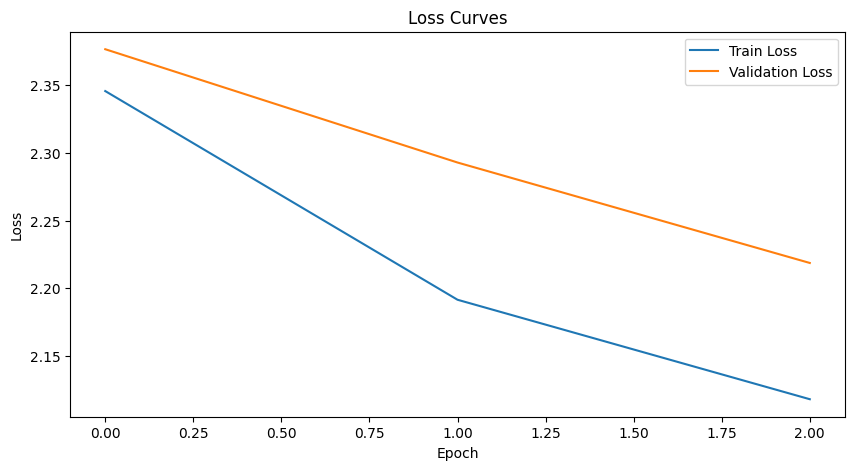

In [23]:
plt.figure(figsize=(10,5))

plt.plot(
    train_losses,
    label='Train Loss'
)

plt.plot(
    val_losses,
    label='Validation Loss'
)

plt.title("Loss Curves")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

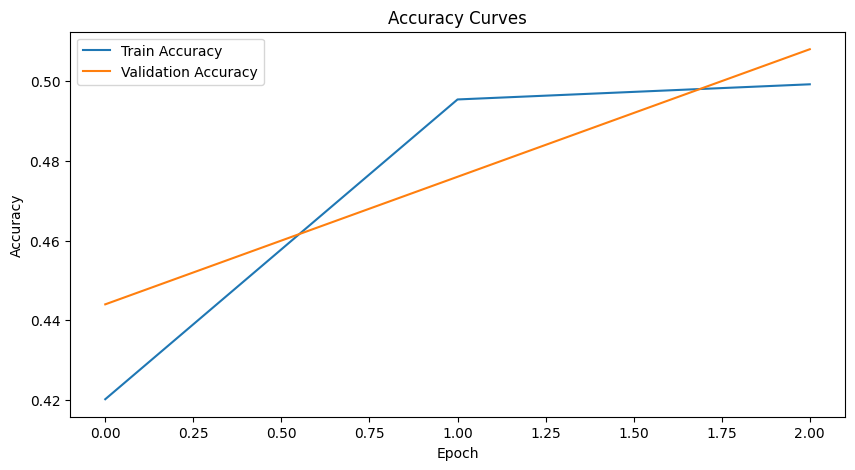

In [24]:
plt.figure(figsize=(10,5))

plt.plot(
    train_accuracies,
    label='Train Accuracy'
)

plt.plot(
    val_accuracies,
    label='Validation Accuracy'
)

plt.title("Accuracy Curves")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [25]:
print("\n" + "="*60)
print("TRAINING COMPLETED SUCCESSFULLY")
print("="*60)

print(f"""
Architecture        : MobileNetV2

Device              : CPU

Epochs              : {EPOCHS}

Batch Size          : {BATCH_SIZE}

Learning Rate       : {LEARNING_RATE}

Number of Classes   : {NUM_CLASSES}

Best Validation Loss: {best_val_loss:.4f}

Model Ready For Evaluation
""")


TRAINING COMPLETED SUCCESSFULLY

Architecture        : MobileNetV2

Device              : CPU

Epochs              : 3

Batch Size          : 8

Learning Rate       : 0.0001

Number of Classes   : 14

Best Validation Loss: 2.2186

Model Ready For Evaluation

